In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

Mounted at /content/drive


In [2]:
import math
import os, shutil, zipfile, json, re, random, collections, logging
from PIL import Image
import cv2
from tqdm.auto import tqdm
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader

from typing import List, Dict, Any

## Mount Drive, set paths, install

In [3]:
PROJECT_NAME = 'VU_DL_Team_Project'
DRIVE_ROOT   = Path('/content/drive/MyDrive') / PROJECT_NAME if IN_COLAB \
               else Path('./drive_local') / PROJECT_NAME

DATA_SUBDIR = 'pii_v1'
DATA_DRIVE   = DRIVE_ROOT / 'data' / DATA_SUBDIR
OUTPUTS      = DRIVE_ROOT / 'outputs'
ADAPTER_DIR  = OUTPUTS / 'lora_adapters' / 'final'
CKPT_DIR     = OUTPUTS / 'checkpoints'

# Local fast scratch for images
LOCAL_SCRATCH = Path('/content/scratch') if IN_COLAB else Path('./scratch')
DATA_LOCAL    = LOCAL_SCRATCH / DATA_SUBDIR

for p in [DATA_DRIVE, OUTPUTS, ADAPTER_DIR, CKPT_DIR, DATA_LOCAL]:
    p.mkdir(parents=True, exist_ok=True)

# Required files
KEEP_FILES = ['train.jsonl', 'val.jsonl', 'test.jsonl', 'images.zip']

if IN_COLAB:
    # Check if all required files exist
    missing_files = [f for f in KEEP_FILES if not (DATA_DRIVE / f).exists()]

    if missing_files:
        print(f"Missing files: {missing_files}. Starting target-only download...")

        # 1. TELL THE CODE THE EXACT FILE IDs (Don't use the folder ID anymore)
        # To get these, right-click the file in Drive -> Share -> Copy Link.
        # The ID is the long string of letters and numbers in the middle of the link.
        FILE_IDS = {
            'train.jsonl': '1k4I7Dm_Zi52bR8gL2I4Vd1DEkAU1u_qT',
            'val.jsonl':   '1mrXN21YuQw-yWmNRrPosXvk2gB4sQZuS',
            'test.jsonl':  '16KRCMg8UUQS-YBuUkk1OMv-xMwcv0v2s',
            'images.zip':  '1tEkIGSHTAHjQgCdSSppRbpPh3IYki7Kv'
        }

        # 2. Loop through and download ONLY the missing files
        for file_name in missing_files:
            file_id = FILE_IDS.get(file_name)
            if file_id and not file_id.startswith('REPLACE_'):
                print(f"Downloading {file_name}...")
                destination = DATA_DRIVE / file_name

                # Download the single file directly
                !gdown {file_id} -O {str(destination)}
            else:
                print(f"⚠️ Skipping {file_name}: Valid File ID not provided yet.")

        print("✅ Target download check complete!")
    else:
        print("✅ All target files (train, val, test, images.zip) already exist in Drive. Skipping download.")

✅ All target files (train, val, test, images.zip) already exist in Drive. Skipping download.


## Sync data to local disk (fast training reads)

In [4]:
# Copy JSONL files (tiny)
for split in ['train.jsonl', 'val.jsonl', 'test.jsonl']:
    src = DATA_DRIVE / split
    dst = DATA_LOCAL / split
    if src.exists() and not dst.exists():
        shutil.copy(src, dst)
        print(f'Copied {split}')

# Unzip images to local disk (only once per session)
images_local = DATA_LOCAL / 'images'
if not images_local.exists() or not any(images_local.iterdir()):
    images_zip = DATA_DRIVE / 'images.zip'
    assert images_zip.exists(), f'Missing {images_zip} — re-run notebook 01 section 9'
    print(f'Unzipping {images_zip.stat().st_size/1e6:.1f} MB to local disk...')
    with zipfile.ZipFile(images_zip) as zf:
        zf.extractall(DATA_LOCAL)
    print(f'✅ {len(list(images_local.iterdir()))} images unzipped')
else:
    print(f'✅ images already on local disk: {len(list(images_local.iterdir()))}')

Copied train.jsonl
Copied val.jsonl
Copied test.jsonl
Unzipping 1541.9 MB to local disk...
✅ 3645 images unzipped


## Sanity check — object-count & label distribution

In [5]:
for split in ['train.jsonl', 'val.jsonl', 'test.jsonl']:
    p = DATA_LOCAL / split
    if not p.exists():
        print(f'(skipping {split} — not found)'); continue
    rows = [json.loads(l) for l in open(p)]
    obj_counts = collections.Counter(len(r['objects']) for r in rows)
    labels = collections.Counter(o['label'] for r in rows for o in r['objects'])
    total_screens = sum(obj_counts.values())
    over_cap = sum(v for k, v in obj_counts.items() if k > 12)
    print(f'\n── {split}  ({total_screens} screens) ──')
    print('  objects/screen:', dict(sorted(obj_counts.items())))
    print(f'  screens with >12 boxes (over current MAX_OBJECTS): {over_cap}')
    print('  label distribution:', dict(labels.most_common()))


── train.jsonl  (2916 screens) ──
  objects/screen: {0: 454, 1: 1941, 2: 373, 3: 95, 4: 30, 5: 17, 6: 2, 7: 1, 8: 2, 9: 1}
  screens with >12 boxes (over current MAX_OBJECTS): 0
  label distribution: {'email_address': 1165, 'phone_number': 537, 'address': 472, 'username': 390, 'transaction_amount': 205, 'date_of_birth': 201, 'full_name': 137, 'account_balance': 114}

── val.jsonl  (364 screens) ──
  objects/screen: {0: 46, 1: 245, 2: 47, 3: 18, 4: 2, 5: 5, 10: 1}
  screens with >12 boxes (over current MAX_OBJECTS): 0
  label distribution: {'email_address': 166, 'address': 78, 'username': 52, 'phone_number': 49, 'date_of_birth': 30, 'full_name': 29, 'transaction_amount': 26, 'account_balance': 6}

── test.jsonl  (365 screens) ──
  objects/screen: {0: 55, 1: 240, 2: 49, 3: 16, 4: 1, 5: 2, 6: 1, 8: 1}
  screens with >12 boxes (over current MAX_OBJECTS): 0
  label distribution: {'email_address': 152, 'phone_number': 60, 'address': 53, 'username': 51, 'transaction_amount': 38, 'date_of_bir

## Stage 2. Finetuning Gemma 4

In [6]:
# Copy Gemma JSONL files (tiny)
for split in ['gemma_train.jsonl', 'gemma_val.jsonl', 'gemma_test.jsonl']:
    src = DATA_DRIVE / split
    dst = DATA_LOCAL / split
    if src.exists() and not dst.exists():
        shutil.copy(src, dst)
        print(f'Copied {split}')

Copied gemma_train.jsonl
Copied gemma_val.jsonl
Copied gemma_test.jsonl


In [22]:
# Copy Gemma JSONL files (tiny)
for split in ['train_ocr.jsonl', 'val_ocr.jsonl', 'test_ocr.jsonl']:
    src = DATA_DRIVE / split
    dst = DATA_LOCAL / split
    if src.exists() and not dst.exists():
        shutil.copy(src, dst)
        print(f'Copied {split}')

Copied train_ocr.jsonl
Copied val_ocr.jsonl
Copied test_ocr.jsonl


In [7]:
!pip install -q \
  "transformers>=4.45" "accelerate>=0.34" "peft>=0.13" "bitsandbytes>=0.43" \
  "datasets" "pytorch-lightning>=2.4" "pillow"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 106.2 MB/s eta 0:00:00


In [8]:
!pip install -q --upgrade transformers peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 130.1 MB/s eta 0:00:00


In [9]:
from PIL import Image
import cv2
from tqdm.auto import tqdm
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import bitsandbytes as bnb

from typing import List, Dict, Any

SEED = 42
pl.seed_everything(SEED, workers=True)
torch.set_float32_matmul_precision('medium')

INFO:lightning_fabric.utilities.seed:Seed set to 42


### Dataset, Model, Training

### Config

In [10]:
try:
    import google.colab
    DATA_LOCAL = Path('/content/scratch/pii_v1')
    CKPT_DIR = Path('/content/drive/MyDrive/VU_DL_Team_Project/outputs/gemma4_checkpoints')
except ImportError:
    DATA_LOCAL = Path('./scratch/pii_v1')
    CKPT_DIR = Path('./outputs/gemma4_checkpoints')

CKPT_DIR.mkdir(parents=True, exist_ok=True)

# google/gemma-2-9b-it — 9B instruction-tuned, much stronger out-of-the-box
# Qwen/Qwen2.5-7B-Instruct — excellent at JSON output, strong PII priors

MODEL_ID = "google/gemma-4-E4B"
BATCH_SIZE = 2
MAX_EPOCHS = 8
LEARNING_RATE = 2e-5

In [11]:
class GemmaFinetuneDataset(Dataset):
    def __init__(self, jsonl_path: Path, data_local_dir: Path):
        self.data = []

        with open(jsonl_path, 'r') as f:
            for line in f:
                self.data.append(json.loads(line))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        # We no longer need to load the physical image into memory!
        return {
            "prompt": row["prompt"],
            "answer": row["answer"]
        }


class GemmaDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

        # Ensure padding tokens exist
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def __call__(self, batch):
        SEP = "\n###ANSWER###\n"
        prompts = [item['prompt'] + SEP for item in batch]
        answers = [item['answer'] + self.tokenizer.eos_token for item in batch]
        full_texts = [p + a for p, a in zip(prompts, answers)]

        inputs = self.tokenizer(
            full_texts, return_tensors="pt", padding=True,
            truncation=True, max_length=1536,   # up from 1024 — coords add tokens
        )

        labels = inputs["input_ids"].clone()
        sep_ids = self.tokenizer(SEP, add_special_tokens=False).input_ids

        for i in range(len(batch)):
            ids = inputs["input_ids"][i].tolist()
            # Find the END position of the separator in the tokenized sequence
            boundary = -1
            for j in range(len(ids) - len(sep_ids) + 1):
                if ids[j:j+len(sep_ids)] == sep_ids:
                    boundary = j + len(sep_ids)
                    break
            if boundary == -1:
                # Fallback: mask everything (won't contribute to loss)
                boundary = len(ids)
            labels[i, :boundary] = -100
            labels[i, inputs["attention_mask"][i] == 0] = -100

        inputs["labels"] = labels
        return inputs


class Gemma4QLoRA(pl.LightningModule):
    def __init__(self, model_id: str, learning_rate: float):
        super().__init__()
        self.save_hyperparameters()

        print(f"⏳ Loading base model: {model_id} in 4-bit...")
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True
        )

        base_model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map="auto"
        )

        base_model = prepare_model_for_kbit_training(base_model)

        # We use a Regex string to explicitly target ONLY the Language Model
        lora_config = LoraConfig(
            r=32,
            lora_alpha=64,
            target_modules=".*language_model.*(q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)",
            bias="none",
            task_type="CAUSAL_LM"
        )

        self.model = get_peft_model(base_model, lora_config)
        self.model.print_trainable_parameters()

        self.model.config.use_cache = False

    def training_step(self, batch, batch_idx):
        # We no longer pass pixel_values to the model
        outputs = self.model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )
        loss = outputs.loss
        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        outputs = self.model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )
        val_loss = outputs.loss
        self.log("val_loss", val_loss, prog_bar=True, sync_dist=True)
        return val_loss

    def configure_optimizers(self):
        optimizer = bnb.optim.PagedAdamW8bit(self.parameters(), lr=self.hparams.learning_rate)

        total_steps = self.trainer.estimated_stepping_batches
        warmup_steps = int(0.1 * total_steps)

        scheduler = get_cosine_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1,
            }
        }

In [ ]:
# Initialize Tokenizer directly (Using AutoTokenizer instead of AutoProcessor)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# Setup Datasets & DataLoaders
train_dataset = GemmaFinetuneDataset(DATA_LOCAL / "gemma_train.jsonl", DATA_LOCAL)
val_dataset = GemmaFinetuneDataset(DATA_LOCAL / "gemma_val.jsonl", DATA_LOCAL)

collator = GemmaDataCollator(tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=2)

# Initialize Model
model = Gemma4QLoRA(model_id=MODEL_ID, learning_rate=LEARNING_RATE)

# Setup Callbacks
checkpoint_callback = ModelCheckpoint(
    dirpath=CKPT_DIR,
    filename="gemma4-pii-{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    mode="min",
    save_top_k=2
)

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    min_delta=0.01
)

# Initialize Trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="gpu",
    devices=1,
    precision="bf16-mixed",
    callbacks=[checkpoint_callback,
               early_stop_callback,
               LearningRateMonitor(logging_interval='step')],
    accumulate_grad_batches=4,
    val_check_interval=0.5,
    log_every_n_steps=10
)

trainer.fit(model, train_loader, val_loader)

⏳ Loading base model: google/gemma-4-E4B in 4-bit...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


trainable params: 69,763,072 || all params: 8,010,863,904 || trainable%: 0.8709


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ PeftModelForCausalLM │  5.8 B │ train │     0 │
└───┴───────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 69.8 M                                                                                           
Non-trainable params: 5.7 B                                                                                        
Total params: 5.8 B                                                                                                
Total estimated model params size (MB): 23,173.682                                                                 
Modules in train mode: 2582                                                                                        
Modules in eval mode: 1758                                                                                         
Total FLOPs: 0

Output()

In [ ]:
CKPT_DIR = Path('/content/drive/MyDrive/VU_DL_Team_Project/outputs/gemma4_checkpoints')
HF_ADAPTER_DIR = Path('/content/drive/MyDrive/VU_DL_Team_Project/outputs/gemma4_hf_adapter')

checkpoints = list(CKPT_DIR.glob("*.ckpt"))
if not checkpoints:
    raise FileNotFoundError(f"No checkpoints found in {CKPT_DIR}")

best_ckpt = sorted(checkpoints, key=lambda x: str(x.name))[-1]
print(f"🔍 Found Best Checkpoint: {best_ckpt.name}")

print("⏳ Loading checkpoint into memory...")
lightning_model = Gemma4QLoRA.load_from_checkpoint(best_ckpt, strict=False)

hf_peft_model = lightning_model.model

print(f"💾 Saving clean Hugging Face LoRA adapter to {HF_ADAPTER_DIR}...")
hf_peft_model.save_pretrained(HF_ADAPTER_DIR)

print("✅ Extraction Complete! Your pure LoRA weights are safely on Google Drive.")

🔍 Found Best Checkpoint: gemma4-pii-epoch=04-val_loss=0.10.ckpt
⏳ Loading checkpoint into memory...
⏳ Loading base model: google/gemma-4-E4B in 4-bit...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

trainable params: 69,763,072 || all params: 8,010,863,904 || trainable%: 0.8709
💾 Saving clean Hugging Face LoRA adapter to /content/drive/MyDrive/VU_DL_Team_Project/outputs/gemma4_hf_adapter...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['model.base_model.model.model.vision_tower.patch_embedder.input_proj.weight.absmax', 'model.base_model.model.model.vision_tower.patch_embedder.input_proj.weight.quant_map', 'model.base_model.model.model.vision_tower.patch_embedder.input_proj.weight.nested_absmax', 'model.base_model.model.model.vision_tower.patch_embedder.input_proj.weight.nested_quant_map', 'model.base_model.model.model.vision_tower.patch_embedder.input_proj.weight.quant_state.bitsandbytes__nf4', 'model.base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.linear.weight.absmax', 'model.base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.linear.weight.quant_map', 'model.base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.linear.weight.nested_absmax', 'model.base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_

✅ Extraction Complete! Your pure LoRA weights are safely on Google Drive.


In [12]:
def extract_json_from_output(text: str) -> dict:
    """Safely extracts a JSON dictionary from LLM generation."""
    try:
        # Find everything between the first { and the last }
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            return json.loads(match.group(0))
        return {}
    except json.JSONDecodeError:
        return None # Indicates formatting failure

In [13]:
from peft import PeftModel

MODEL_ID = "google/gemma-4-E4B"
HF_ADAPTER_DIR = Path('/content/drive/MyDrive/VU_DL_Team_Project/outputs/gemma4_hf_adapter')
TEST_DATA_PATH = Path('/content/scratch/pii_v1/gemma_test.jsonl')
ALLOWED = {'email_address', 'phone_number', 'full_name', 'username', 'address',
           'date_of_birth', 'account_balance', 'transaction_amount', 'other_sensitive'}

print(f"⏳ Loading Base Model in 4-bit: {MODEL_ID}")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

print(f"⏳ Loading LoRA Adapters from: {HF_ADAPTER_DIR}")
model = PeftModel.from_pretrained(base_model, HF_ADAPTER_DIR)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

y_true_list = []
y_pred_list = []
formatting_failures = 0

print("🚀 Starting Batched Inference...")

with open(TEST_DATA_PATH, 'r') as f:
    test_lines = f.readlines()

BATCH_SIZE = 16
total_batches = math.ceil(len(test_lines) / BATCH_SIZE)

for batch_idx in tqdm(range(total_batches), desc="Processing Batches"):
    start_idx = batch_idx * BATCH_SIZE
    end_idx = start_idx + BATCH_SIZE
    batch_lines = test_lines[start_idx:end_idx]

    batch_prompts = []
    batch_truths = []

    for line in batch_lines:
        row = json.loads(line)
        batch_prompts.append(row["prompt"] + "\n###ANSWER###\n")
        batch_truths.append(json.loads(row["answer"]))

    inputs = tokenizer(
        batch_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,           # up from 150 — bigger prompts produce bigger answers
            do_sample=False,
            num_beams=1,                  # greedy is fine and faster
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    input_length = inputs["input_ids"].shape[1]

    for i in range(len(batch_prompts)):
        generated_tokens = generated_ids[i][input_length:]
        generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
        predicted_dict = extract_json_from_output(generated_text)
        if predicted_dict:
            predicted_dict = {k: v for k, v in predicted_dict.items() if v in ALLOWED}

        if predicted_dict is None:
            formatting_failures += 1
            predicted_dict = {}

        y_true_list.append(batch_truths[i])
        y_pred_list.append(predicted_dict)

print("\n" + "="*40)
print("📊 EVALUATION COMPLETE")
print("="*40)

⏳ Loading Base Model in 4-bit: google/gemma-4-E4B


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

🚀 Starting Batched Inference...


Processing Batches:   0%|          | 0/23 [00:00<?, ?it/s]


📊 EVALUATION COMPLETE


In [14]:
# 1. Formatting Metric
total_screens = len(test_lines)
format_success = ((total_screens - formatting_failures) / total_screens) * 100
print(f"✅ JSON Formatting Success Rate: {format_success:.2f}% ({formatting_failures} failures)")

# 2. Information Extraction Metrics
tp_total, fp_total, fn_total = 0, 0, 0
label_metrics = {}

for true_dict, pred_dict in zip(y_true_list, y_pred_list):
    # Get all unique labels involved in this specific screen
    all_labels = set(true_dict.values()).union(set(pred_dict.values()))

    for label in all_labels:
        if label not in label_metrics:
            label_metrics[label] = {"tp": 0, "fp": 0, "fn": 0}

        # Get strings associated with this label
        true_strings = {k for k, v in true_dict.items() if v == label}
        pred_strings = {k for k, v in pred_dict.items() if v == label}

        # Calculate intersections
        tp = len(true_strings.intersection(pred_strings))
        fp = len(pred_strings - true_strings)
        fn = len(true_strings - pred_strings)

        # Aggregate
        label_metrics[label]["tp"] += tp
        label_metrics[label]["fp"] += fp
        label_metrics[label]["fn"] += fn
        tp_total += tp
        fp_total += fp
        fn_total += fn

def calc_f1(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

# Micro Metrics (Global Performance)
micro_p, micro_r, micro_f1 = calc_f1(tp_total, fp_total, fn_total)
print(f"\n🌐 GLOBAL METRICS (Micro-Average)")
print(f"Precision: {micro_p:.4f}")
print(f"Recall:    {micro_r:.4f}")
print(f"F1-Score:  {micro_f1:.4f}")

# Per-Class Metrics (Macro)
print("\n🏷️ PER-CLASS METRICS")
macro_f1_sum = 0
for label, counts in sorted(label_metrics.items()):
    p, r, f1 = calc_f1(counts["tp"], counts["fp"], counts["fn"])
    macro_f1_sum += f1
    print(f"- {label:<15} | P: {p:.2f} | R: {r:.2f} | F1: {f1:.2f}  (TP:{counts['tp']} FP:{counts['fp']} FN:{counts['fn']})")

macro_f1 = macro_f1_sum / len(label_metrics) if label_metrics else 0.0
print(f"\n⚖️ MACRO F1-SCORE: {macro_f1:.4f}")

✅ JSON Formatting Success Rate: 100.00% (0 failures)

🌐 GLOBAL METRICS (Micro-Average)
Precision: 0.7677
Recall:    0.6179
F1-Score:  0.6847

🏷️ PER-CLASS METRICS
- account_balance | P: 0.50 | R: 0.25 | F1: 0.33  (TP:2 FP:2 FN:6)
- address         | P: 0.57 | R: 0.44 | F1: 0.50  (TP:25 FP:19 FN:32)
- date_of_birth   | P: 0.73 | R: 0.83 | F1: 0.77  (TP:24 FP:9 FN:5)
- email_address   | P: 0.94 | R: 0.79 | F1: 0.86  (TP:117 FP:7 FN:31)
- full_name       | P: 0.82 | R: 0.50 | F1: 0.62  (TP:9 FP:2 FN:9)
- phone_number    | P: 0.59 | R: 0.50 | F1: 0.54  (TP:22 FP:15 FN:22)
- transaction_amount | P: 0.59 | R: 0.40 | F1: 0.48  (TP:10 FP:7 FN:15)
- username        | P: 0.70 | R: 0.47 | F1: 0.57  (TP:19 FP:8 FN:21)

⚖️ MACRO F1-SCORE: 0.5838


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random

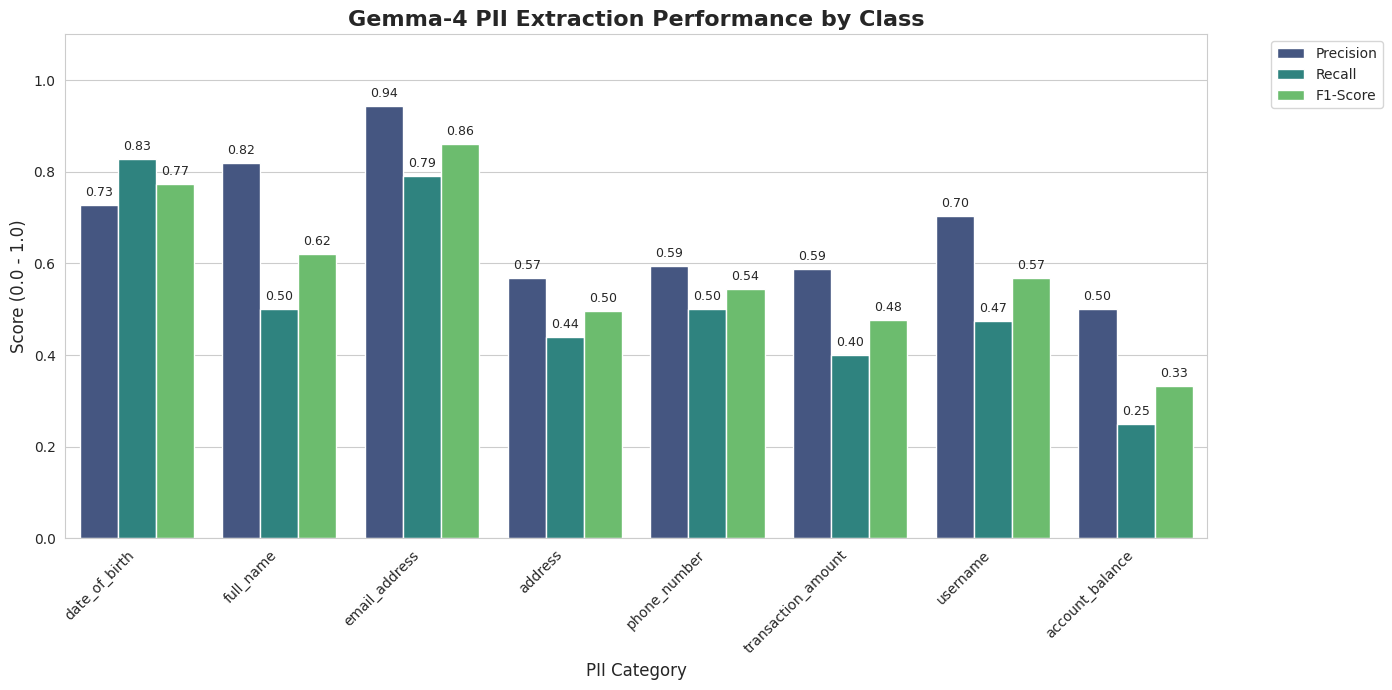

In [16]:
# Prepare data for plotting
plot_data = []
for label, counts in label_metrics.items():
    p, r, f1 = calc_f1(counts['tp'], counts['fp'], counts['fn'])
    plot_data.append({'Label': label, 'Metric': 'Precision', 'Value': p})
    plot_data.append({'Label': label, 'Metric': 'Recall', 'Value': r})
    plot_data.append({'Label': label, 'Metric': 'F1-Score', 'Value': f1})

df_plot = pd.DataFrame(plot_data)

# Create the visualization
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
ax = sns.barplot(x='Label', y='Value', hue='Metric', data=df_plot, palette='viridis')

plt.title('Gemma-4 PII Extraction Performance by Class', fontsize=16, fontweight='bold')
plt.xlabel('PII Category', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Add values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=9)

plt.show()